# Notebook 1 — Exploratory Data Analysis

| | |
|---|---|
| **Objetivo** | Revisar y comprender el dataset. |
| **Dataset** | Palmer Penguins Dataset Extended |
| **Herramientas** | Pandas, matplotlib, seaborn |

---

## Contenido
1. Informacion general
2. Tipos de variables
3. Valores Faltantes
4. Distribuciones
5. Outliers
6. Balance de clases
7. Correlaciones

## 0. Importacion del dataset, copia del mismo y creacion del test_set

In [29]:
# Importacion de librerias necesarias para este notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

In [30]:
df_original = pd.read_csv(r"E:\ROAD_TO_DATA_SCIENCE\PROYECTS\penguin-species-classification\data\raw\palmerpenguins_extended.csv")

In [31]:
df_penguins = df_original.copy()

In [32]:
from sklearn.model_selection import train_test_split
penguin_train_set, penguin_test_set = train_test_split(df_penguins, test_size=0.2, random_state=42)

**Nota:** Se crea esta division desde esta fase tan temprana debido a que el cerebro es una increible maquina de deteccion de patrones, lo que podria despues generar sesgos asi que unicamente se revisaran los datos referentes al penguin_train_set

In [33]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

## 1. Informacion general

In [34]:
penguin_train_set.shape

(2744, 11)

El dataset de train tiene:
- Filas: 2744
- Columnas: 11

In [35]:
penguin_train_set.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
1258,Adelie,Torgensen,30.9,13.7,199.0,4901.0,female,krill,adult,healthy,2023
932,Gentoo,Biscoe,24.8,17.5,205.0,5940.0,male,krill,juvenile,overweight,2022
572,Adelie,Torgensen,62.5,14.5,206.0,4664.0,female,fish,juvenile,overweight,2022
736,Chinstrap,Dream,32.0,17.4,211.0,4357.0,male,krill,juvenile,underweight,2022
2288,Gentoo,Biscoe,56.7,17.7,235.0,5689.0,female,fish,juvenile,overweight,2024


## 2. Tipos de variables

In [36]:
penguin_train_set.info()

<class 'pandas.DataFrame'>
Index: 2744 entries, 1258 to 3174
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            2744 non-null   str    
 1   island             2744 non-null   str    
 2   bill_length_mm     2744 non-null   float64
 3   bill_depth_mm      2744 non-null   float64
 4   flipper_length_mm  2744 non-null   float64
 5   body_mass_g        2744 non-null   float64
 6   sex                2744 non-null   str    
 7   diet               2744 non-null   str    
 8   life_stage         2744 non-null   str    
 9   health_metrics     2744 non-null   str    
 10  year               2744 non-null   int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 257.2 KB


- Cualitativas: 
    - Species
    - Island
    - Sex
    - Diet
    - Life_stage
    - health_metrics
- Cuantitativas:
    - bill_lenght_mm
    - bill_depth_mm
    - flipper_length_mm
    - body_mass_g
    - year


In [37]:
target_col = 'species' # para que devuelva una serie
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']
cat_cols = ['island', 'sex', 'diet', 'life_stage', 'health_metrics']

## 3. Valores Faltantes

In [38]:
# Mostrar cuantos nulos hay y que porcentaje representan por columna
resumen_nulos = penguin_train_set.isna().sum().to_frame(name='Total Nulos')
resumen_nulos['Porcentaje %'] = (penguin_train_set.isna().mean() * 100).round(2)
print(resumen_nulos.sort_values(by='Total Nulos', ascending=False))

                   Total Nulos  Porcentaje %
species                      0           0.0
island                       0           0.0
bill_length_mm               0           0.0
bill_depth_mm                0           0.0
flipper_length_mm            0           0.0
body_mass_g                  0           0.0
sex                          0           0.0
diet                         0           0.0
life_stage                   0           0.0
health_metrics               0           0.0
year                         0           0.0


**Conclusion:** El dataset no presenta valores nulos en ninguna de sus columnas, no habra que realizar imputacion

## 4. Distribuciones

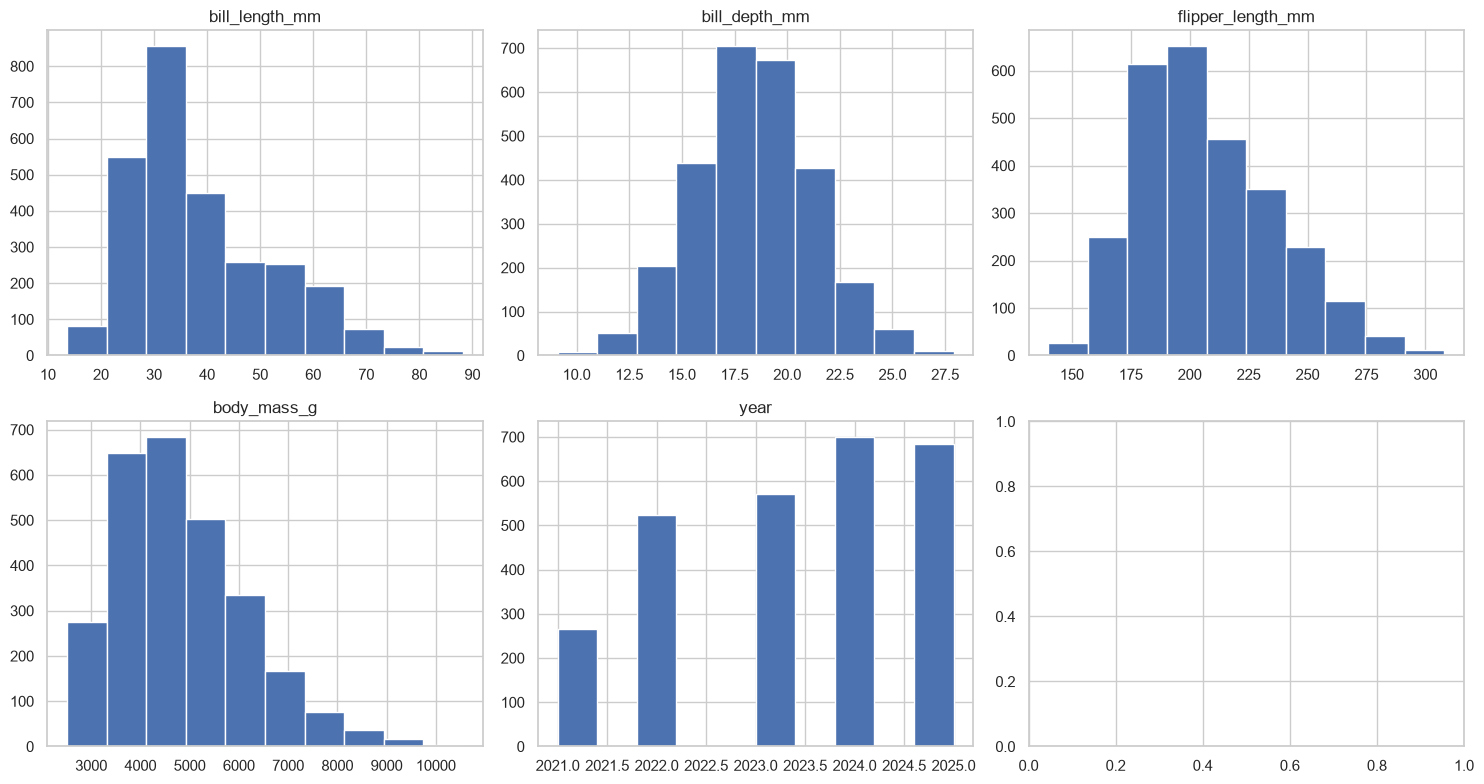

In [49]:
fig, axs = plt.subplots(2, 3, figsize=(15,8))

axs[0,0].hist(penguin_train_set[num_cols[0]])
axs[0,0].set_title(f"{num_cols[0]}")

axs[0,1].hist(penguin_train_set[num_cols[1]])
axs[0,1].set_title(f"{num_cols[1]}")

axs[0,2].hist(penguin_train_set[num_cols[2]])
axs[0,2].set_title(f"{num_cols[2]}")

axs[1,0].hist(penguin_train_set[num_cols[3]])
axs[1,0].set_title(f"{num_cols[3]}")

axs[1,1].hist(penguin_train_set[num_cols[4]])
axs[1,1].set_title(num_cols[4])


plt.tight_layout()
plt.show()

Observaciones:
- bill_length_mm = Distribucion sesgada hacia la izquierda (requiere transformacion)
- bill_depth_mm = Distribucion normal (no requiere transformacion)
- flipper_length_mm = Distribucion sesgada hacia la izquierda (requiere transformacion)
- body_mass_g = Distribucion sesgada hacia la izquierda (requiere transformacion)
- year = Es categorica por eso se observa esa forma de columnas separradas

Ademas todas cuentan con escalas muy distintas, requieren escalamiento, de no realizar estas acciones los modelos podrian darle importancia a valores mas altos sin en realidad tener mas importancia, lo que llevaria a incrementar el error reducible

## 5. Outliers

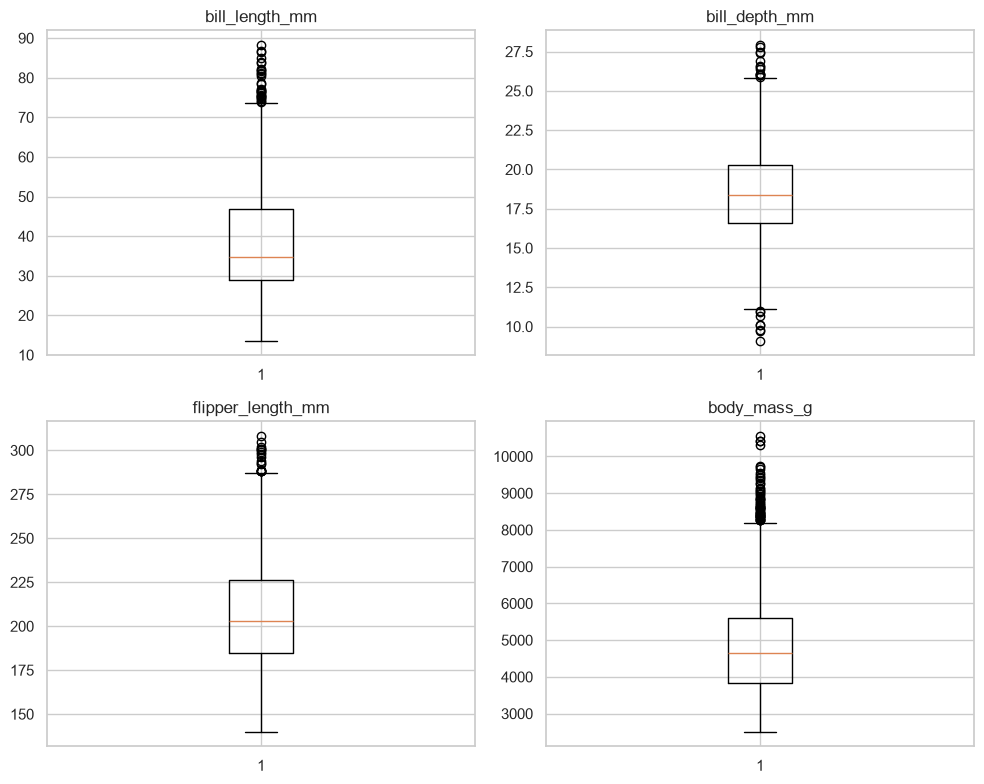

In [40]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))

axs[0,0].boxplot(penguin_train_set[num_cols[0]])
axs[0,0].set_title(f"{num_cols[0]}")

axs[0,1].boxplot(penguin_train_set[num_cols[1]])
axs[0,1].set_title(f"{num_cols[1]}")

axs[1,0].boxplot(penguin_train_set[num_cols[2]])
axs[1,0].set_title(f"{num_cols[2]}")

axs[1,1].boxplot(penguin_train_set[num_cols[3]])
axs[1,1].set_title(f"{num_cols[3]}")



plt.tight_layout()
plt.show()

In [41]:
for i in num_cols:
    # Calcular los cuartiles (Q1 y Q3)
    q1 = penguin_train_set[i].quantile(0.25)
    q3 = penguin_train_set[i].quantile(0.75)

    # Calcular IQR
    iqr = q3 - q1

    # Definir limites
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Filtrar outliers
    outliers = penguin_train_set[(penguin_train_set[i] < limite_inferior) | (penguin_train_set[i] > limite_superior)]

    # Calcular el porcentaje de outliers
    porcentaje_outliers = (len(outliers) / len(penguin_train_set) * 100)

    print(f"Porcentaje de outliers de {i}: {porcentaje_outliers:.2f}%")

Porcentaje de outliers de bill_length_mm: 1.02%
Porcentaje de outliers de bill_depth_mm: 0.77%
Porcentaje de outliers de flipper_length_mm: 0.66%
Porcentaje de outliers de body_mass_g: 1.97%
Porcentaje de outliers de year: 0.00%


**Observaciones:**
- Todas las variables numéricas presentan outliers, pero en proporciones bajas (entre 0 % y 2 %).
- **body_mass_g** es la variable con mayor porcentaje de outliers (1.97 %), seguida de **bill_length_mm** (1.02 %).
- **year** no presenta valores atípicos según el criterio del rango intercuartílico (IQR).

Dado que el porcentaje de outliers es bajo en todas las variables, no se considera necesario aplicar un tratamiento específico, ya que es poco probable que afecten significativamente el rendimiento del modelo.

## 6. Balance de clases

In [42]:
# Categorias en variables categoricas
i = 0
while(i < len(cat_cols)):
    print("-" * 20)
    print(f"Categorias de {cat_cols[i]}")
    print(penguin_train_set[cat_cols[i]].value_counts())
    i+=1

--------------------
Categorias de island
island
Biscoe       1401
Dream         911
Torgensen     432
Name: count, dtype: int64
--------------------
Categorias de sex
sex
male      1382
female    1362
Name: count, dtype: int64
--------------------
Categorias de diet
diet
krill       1123
fish         774
parental     691
squid        156
Name: count, dtype: int64
--------------------
Categorias de life_stage
life_stage
juvenile    1235
adult        818
chick        691
Name: count, dtype: int64
--------------------
Categorias de health_metrics
health_metrics
healthy        1237
overweight      938
underweight     569
Name: count, dtype: int64


**Observaciones:** Ninguna de las variables categoricas tiene una gran cantidad de categorias asi que se puede manejar simplemente con one hot encoding

## 7. Correlaciones

### Correlacion entre features numericas y target categorico

Utilizaremos ANOVA ya que realizaremos una clasificacion multidimensional (3 dimensiones en este caso) si el P-valor es menor a 0.05 esta variable si tiene relacion e impacto con el target (especies)

In [43]:
import scipy.stats as stats

In [44]:
resultados = {}

# Calcular ANOVA para cada variable numerica

for i in num_cols:

    # Agrupar datos numericos segun las 3 categorias del target
    grupos = [penguin_train_set[i][penguin_train_set[target_col] == cat] for cat in penguin_train_set[target_col].dropna().unique()]

    # Ejecutar test ANOVA
    f_stat, p_val = stats.f_oneway(*grupos)
    resultados[i] = {'F-Statistic': f_stat, 'P-Value': p_val}


df_resultados = pd.DataFrame(resultados).T.sort_values(by='P-Value')
print(df_resultados)

                   F-Statistic       P-Value
bill_depth_mm       188.901774  1.392362e-77
body_mass_g         184.916399  4.643636e-76
bill_length_mm      164.614293  3.068130e-68
flipper_length_mm   108.541106  4.313199e-46
year                  0.771736  4.623104e-01


**Observaciones:**
- Todas las variables numéricas, excepto `year`, presentan un **p-value < 0.05**, por lo que existe evidencia estadísticamente significativa de que están relacionadas con la variable objetivo (`species`).
- La variable `year` obtuvo un **F-Statistic = 0.77** y un **p-value = 0.462**, por lo que no existe evidencia estadísticamente significativa de una relación entre esta variable y la especie del pingüino.
- Debido a estos resultados, `year` se considera una **feature candidata a ser eliminada**. La decisión final se tomará durante la etapa de entrenamiento, comparando el rendimiento de los modelos con y sin esta variable.

### Correlacion entre Features numericas

Se utilizara correlacion de person para evaluar si hay presencia de multicolinealidad entre las features, es decir que existe una redundancia, esto no aportaria informacion nueva al modelo sino que mas bien generaria ruido, esto puede causar confusion a los algoritmos.

In [45]:
corr_matrix = penguin_train_set.corr(numeric_only=True, method='pearson')

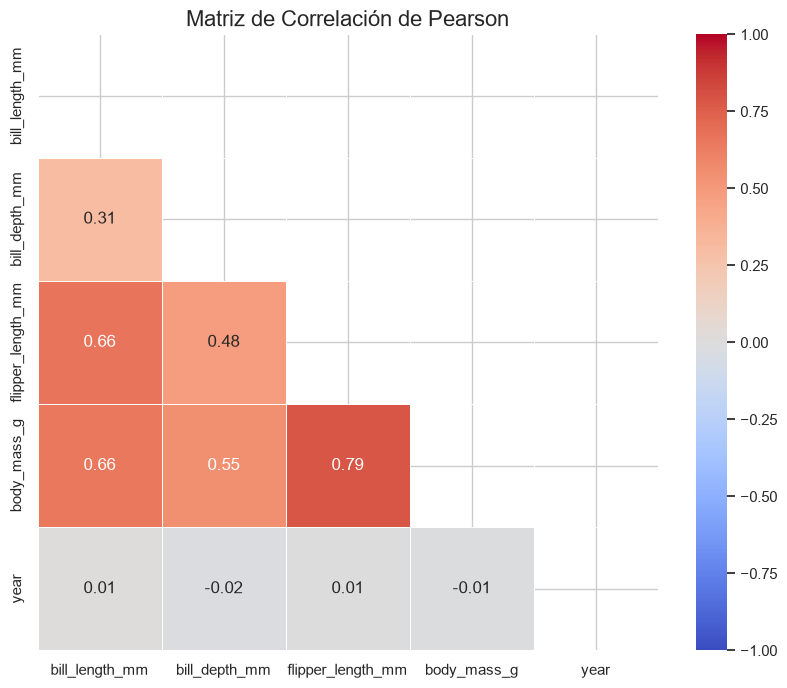

In [46]:
plt.figure(figsize=(10,8))

# Crear una máscara para ocultar la mitad superior del gráfico
# (Como la matriz es un espejo, ver ambos lados genera ruido visual)
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el mapa de calor (heatmap)
sns.heatmap(corr_matrix, 
            mask=mascara,        # Aplica la máscara
            annot=True,          # Muestra el número exacto de la correlación
            fmt=".2f",           # Redondea a 2 decimales
            cmap='coolwarm',     # Colores: Rojo (positiva) y Azul (negativa)
            vmin=-1, vmax=1,     # Fija la escala rígidamente entre -1 y 1
            linewidths=0.5)      # Añade líneas de separación entre celdas

plt.title('Matriz de Correlación de Pearson', fontsize=16)
plt.show()


**Observaciones:**
- El nivel de correlacion es alto unicamente entre ``flipper_length_mm`` y ``body_mass_g``

Se toma la decision de mantener estas features en el dataset ya que el objetivo de este proyecto es el de obtener la mejor prediccion posible, es decir, se utilizara un paradigma de prediccion no de inferencia. Aunque estas dos features comparten gran parte de la informacion que el modelo entendera, aun asi hay una parte que puede servir para que el modelo extraiga y pueda realizar mejores predicciones.

### Correlacion entre features categoricas y target

In [48]:
for col in cat_cols:
    # 1. Crear la tabla de contingencia (Frecuencias Observadas)
    # Esto cuenta cuántas veces aparece cada combinación de categoría
    tabla_contingencia = pd.crosstab(penguin_train_set[col], penguin_train_set['species'])

    print("--- Tabla de Contingencia (Observada) ---")
    print(tabla_contingencia)

    # 2. Ejecutar el test de Chi-Cuadrado
    chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia)

    print(f"Estadistico Chi-Cuadrado: {chi2:.4f}")
    print(f"P-Value: {p_val:.4e}")
    print("\n")

--- Tabla de Contingencia (Observada) ---
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe        411          0     990
Dream         413        498       0
Torgensen     432          0       0
Estadistico Chi-Cuadrado: 2311.2888
P-Value: 0.0000e+00


--- Tabla de Contingencia (Observada) ---
species  Adelie  Chinstrap  Gentoo
sex                               
female      626        272     464
male        630        226     526
Estadistico Chi-Cuadrado: 7.9992
P-Value: 1.8323e-02


--- Tabla de Contingencia (Observada) ---
species   Adelie  Chinstrap  Gentoo
diet                               
fish         309         79     386
krill        546        266     311
parental     333        123     235
squid         68         30      58
Estadistico Chi-Cuadrado: 118.4110
P-Value: 3.5136e-23


--- Tabla de Contingencia (Observada) ---
species     Adelie  Chinstrap  Gentoo
life_stage                           
adult          371        133     314
chick  

**Observaciones:**
- De las 5 features categoricas unicamente una no esta relacionada con el target, esta feature es ``life_stage``, debido a que su P-Value es mayor a 0.05, podriamos inferir que la especie es independiente de la etapa de vida en la que se encuentre un pinguino. Se toma como decision eliminar esta columna con el fin de no aumentar la dimensionalidad del dataset con una feature que no representara un efecto positivo en la capacidad de clasificacion de los modelos, todo lo contrario mantenerla llevaria a consumir mas memoria, y en el peor de los casos overfitting.



## 8. Conclusiones

**Valores faltantes**
- El dataset (2744 filas, 11 columnas) no presenta valores nulos en ninguna columna, por lo que no se necesita imputación ni ningún tratamiento adicional.

**Variables categóricas**
- Hay 5 variables categóricas (`island`, `sex`, `diet`, `life_stage`, `health_metrics`) frente a 5 numéricas.
- Ninguna variable categórica presenta una cantidad elevada de categorías, por lo que pueden codificarse mediante One-Hot Encoding.

**Distribuciones numéricas**
- La mayoría de las variables numéricas muestran sesgo hacia la izquierda (`bill_length_mm`, `flipper_length_mm` y `body_mass_g`), por lo que requerirán una transformación para reducir dicho sesgo.
- Además, al encontrarse en escalas muy diferentes, será necesario aplicar un método de escalamiento para evitar que el modelo otorgue mayor importancia a variables únicamente por la magnitud de sus valores.
- Los outliers detectados representan un porcentaje bajo en todas las variables (entre 0 % y 1.97 %), por lo que no se considera necesario aplicar un tratamiento específico para ellos.

**Correlaciones y decisión final**
- La prueba ANOVA mostró que no todas las variables numéricas presentan una relación estadísticamente significativa con la variable objetivo; `year` obtuvo un **p-value = 0.462**, por lo que no existe evidencia suficiente de que contribuya a diferenciar las especies.
- Además, `year` presentó correlaciones de Pearson muy bajas con el resto de las variables numéricas, lo que sugiere que aporta poca información al conjunto de datos.
- Debido a esta evidencia, `year` se considera una **feature candidata a ser eliminada**. No obstante, la decisión final se tomará durante la etapa de entrenamiento, comparando el rendimiento de los modelos con y sin esta variable.
- Existe una correlación moderada entre `flipper_length_mm` y `body_mass_g`; sin embargo, dado que el objetivo del proyecto es maximizar la capacidad predictiva del modelo, ambas variables se conservarán para evaluar su aporte durante el entrenamiento.
- La única feature que será eliminada en esta etapa es `life_stage`, ya que la prueba de independencia obtuvo un **p-value > 0.05**, indicando que no existe evidencia estadísticamente significativa de una relación entre esta variable y la especie del pingüino.